<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-635/162702126.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-635/162702126.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Final Model Accuracy: 0.7926267281105991
[[116  30]
 [ 15  56]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       146
           1       0.65      0.79      0.71        71

    accuracy                           0.79       217
   macro avg       0.77      0.79      0.78       217
weighted avg       0.81      0.79      0.80       217



/tmp/ipython-input-635/162702126.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette="Set1")
/tmp/ipython-input-635/162702126.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[1], palette="Set2")


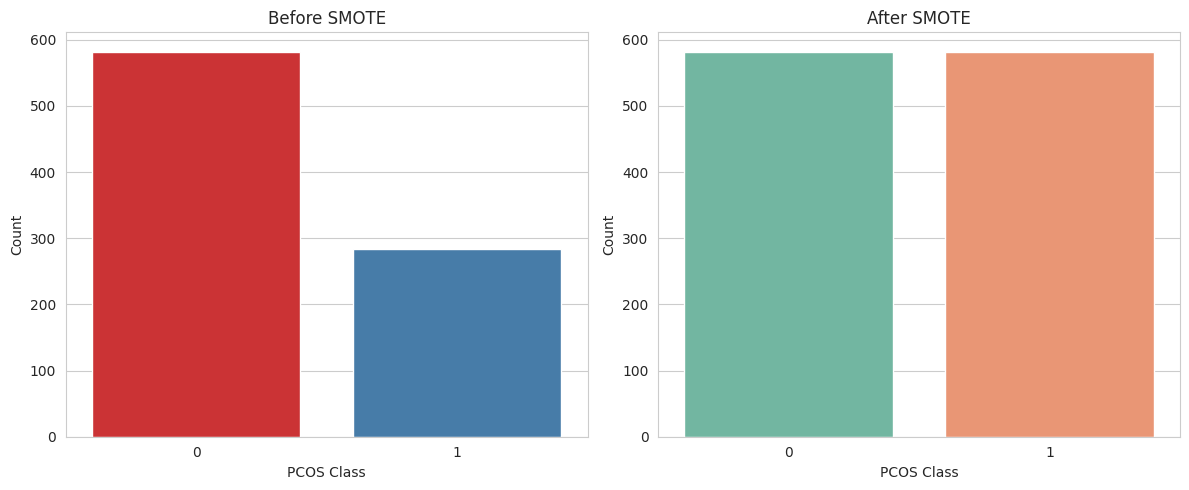

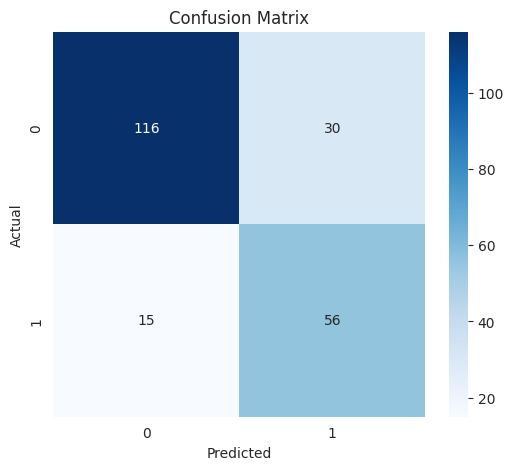

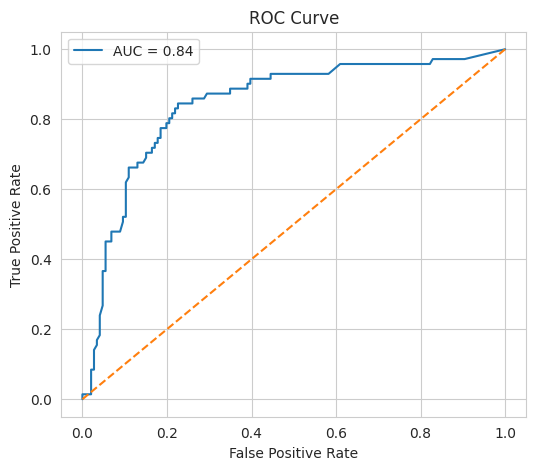

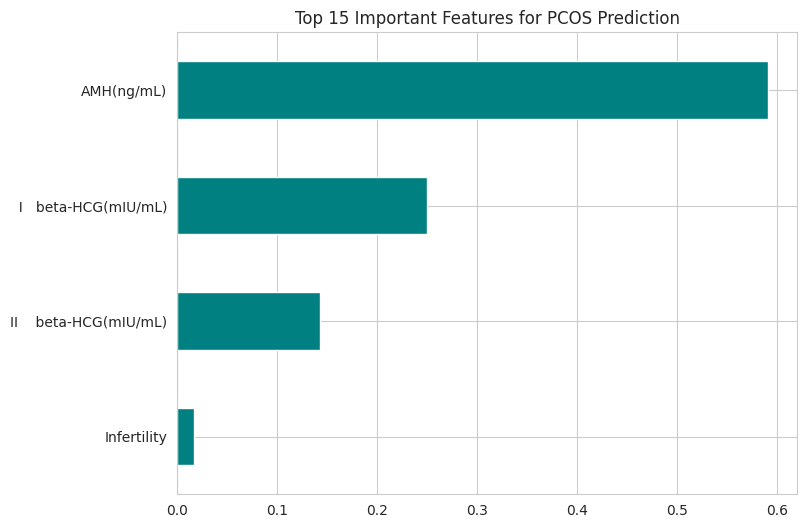

/tmp/ipython-input-635/162702126.py:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=risk_df["PCOS_Risk_Level"], palette="coolwarm")


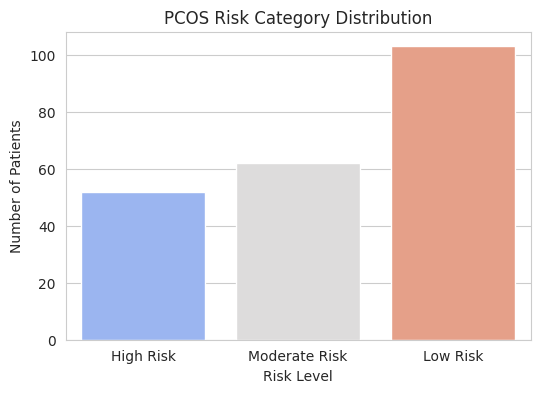

✅ Prediction CSV created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PCOS Risk Probability: 0.0
PCOS Risk Level: Low Risk


In [3]:
!pip install imbalanced-learn xgboost openpyxl

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from google.colab import files

# ================= LOAD DATA =================
df_main = pd.read_excel("PCOS_data_without_infertility.xlsx", sheet_name="Full_new")
df_infert = pd.read_csv("PCOS_infertility.csv")

df_main["Infertility"] = 0
df_infert["Infertility"] = 1

drop_cols = ["Sl. No", "Patient File No.", "Unnamed: 44"]
df_main.drop(columns=drop_cols, inplace=True, errors="ignore")
df_infert.drop(columns=drop_cols, inplace=True, errors="ignore")

common_cols = list(set(df_main.columns).intersection(set(df_infert.columns)))
df_main = df_main[common_cols]
df_infert = df_infert[common_cols]

df = pd.concat([df_main, df_infert], axis=0, ignore_index=True)

# Save combined dataset
df.to_csv("PCOS_combined_dataset.csv", index=False)
files.download("PCOS_combined_dataset.csv")

# ================= HANDLE MISSING =================
for col in df.columns:
    if df[col].dtype != "object":
        df[col].fillna(df[col].median(), inplace=True)

# ================= SPLIT FEATURES & TARGET =================
X = df.drop("PCOS (Y/N)", axis=1)
y = df["PCOS (Y/N)"].astype(int)

# Keep original test data for final CSV
X_original = X.copy()

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test, X_train_orig, X_test_orig = train_test_split(
    X, y, X_original,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert to numeric
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

# ================= SCALING =================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================= SMOTE =================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# ================= FINAL MODEL =================
final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X_train_smote, y_train_smote)

# ================= PREDICTIONS =================
y_pred = final_model.predict(X_test_scaled)
pcos_risk_prob = final_model.predict_proba(X_test_scaled)[:, 1]

print("Final Model Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ================= RISK CATEGORY =================
def risk_category(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Moderate Risk"
    else:
        return "High Risk"

# ================= CREATE FINAL OUTPUT =================
risk_df = X_test_orig.copy()

risk_df["Actual_PCOS"] = y_test.values
risk_df["Predicted_PCOS"] = y_pred
risk_df["PCOS_Risk_Probability"] = pcos_risk_prob
risk_df["PCOS_Risk_Level"] = risk_df["PCOS_Risk_Probability"].apply(risk_category)

# ================= VISUALIZATION SECTION =================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_style("whitegrid")

# 🎯 1. Class distribution BEFORE & AFTER SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0], palette="Set1")
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("PCOS Class")
axes[0].set_ylabel("Count")

sns.countplot(x=y_train_smote, ax=axes[1], palette="Set2")
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("PCOS Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


# 🎯 2. Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 🎯 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, pcos_risk_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# 🎯 4. Feature Importance (Top 15)
importances = final_model.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(15).plot(kind="barh", color="teal")
plt.title("Top 15 Important Features for PCOS Prediction")
plt.gca().invert_yaxis()
plt.show()


# 🎯 5. Risk Level Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=risk_df["PCOS_Risk_Level"], palette="coolwarm")
plt.title("PCOS Risk Category Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()


# ================= SAVE CSV =================
risk_df.to_csv("PCOS_risk_predictions.csv", index=False)

print("✅ Prediction CSV created")

# ================= DOWNLOAD CSV =================
files.download("PCOS_risk_predictions.csv")

# ================= SAVE MODEL =================
joblib.dump(final_model, "pcos_model.pkl")
joblib.dump(scaler, "pcos_scaler.pkl")

files.download("pcos_model.pkl")
files.download("pcos_scaler.pkl")

# ================= NEW PATIENT TEST =================
new_patient = X.iloc[0:1]

new_patient_scaled = scaler.transform(new_patient)

risk_prob = final_model.predict_proba(new_patient_scaled)[0][1]
risk_level = risk_category(risk_prob)

print("PCOS Risk Probability:", round(risk_prob, 2))
print("PCOS Risk Level:", risk_level)